# 00. RC 병렬 임피던스와 나이퀴스트 선도

**목적**: `docs/02_theory/W2_eis.md` M2.1~M2.2에서 손으로 유도/계산한 내용을
코드로 재현하고 검증한다.

1. RC 병렬 임피던스가 나이퀴스트 평면에서 정확히 반원을 그리는지 확인
2. 두 개의 RC 블록을 직렬로 연결했을 때, 시상수(τ)가 충분히 다르면
   반원이 분리되고, 가까우면 뭉개진다는 것을 직접 확인
   (W2.2에서 τ1=2s, τ2=100s로 손계산했던 것과 동일 설정)

(그래프 안의 텍스트는 폰트 호환성을 위해 영어로 표기합니다.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 6)
plt.rcParams['font.size'] = 11


## 1. RC 병렬 임피던스 함수

W2.1에서 유도한 식:

$$Z(\omega) = \frac{R}{1+j\omega RC}$$


In [2]:
def z_rc_parallel(omega, R, C):
    """RC 병렬 임피던스. omega: 각주파수 배열 [rad/s]"""
    return R / (1 + 1j * omega * R * C)


def z_series(*impedances):
    """임피던스들을 직렬로 합산 (W2.2: 직렬은 그냥 더한다)"""
    total = np.zeros_like(impedances[0], dtype=complex)
    for z in impedances:
        total = total + z
    return total


## 2. 반원 하나 확인 — R=1, C=1

W2.1에서 손으로 계산했던 것과 동일한 설정. 반원의 지름이 R(=1)이고,
꼭대기 주파수가 1/RC(=1 rad/s)여야 한다.


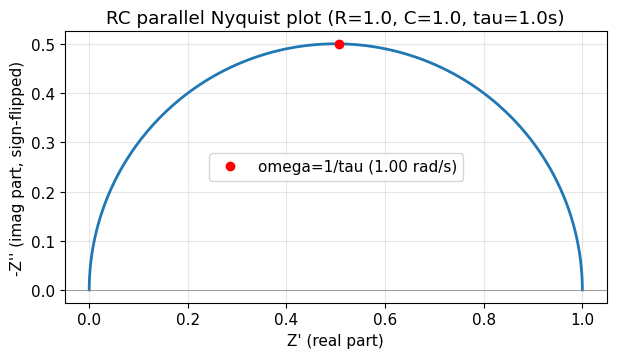

반원 지름(실측) = 1.0000 (기대값: R=1.0)
꼭대기에서 Z'=0.5069 (기대값: R/2=0.5)


In [3]:
R, C = 1.0, 1.0
tau = R * C
omega = np.logspace(-3, 3, 500)  # 0.001 ~ 1000 rad/s

Z = z_rc_parallel(omega, R, C)

fig, ax = plt.subplots()
ax.plot(Z.real, -Z.imag, lw=2)
ax.set_xlabel("Z' (real part)")
ax.set_ylabel("-Z'' (imag part, sign-flipped)")
ax.set_title(f"RC parallel Nyquist plot (R={R}, C={C}, tau={tau}s)")
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5)
ax.grid(alpha=0.3)

idx_peak = np.argmin(np.abs(omega - 1/tau))
ax.plot(Z.real[idx_peak], -Z.imag[idx_peak], 'ro', label=f'omega=1/tau ({1/tau:.2f} rad/s)')
ax.legend()
plt.show()

print(f"반원 지름(실측) = {Z.real.max() - Z.real.min():.4f} (기대값: R={R})")
print(f"꼭대기에서 Z'={Z.real[idx_peak]:.4f} (기대값: R/2={R/2})")


## 3. 시상수가 충분히 다른 두 RC — 반원이 분리되는가

W2.2에서 손계산했던 설정 그대로: R0=0.01, 블록1(R1=0.02, C1=100 → τ1=2s),
블록2(R2=0.05, C2=2000 → τ2=100s). τ2/τ1 = 50배 차이.


tau1 = 2.0s, tau2 = 100.0s, 비율 = 50배


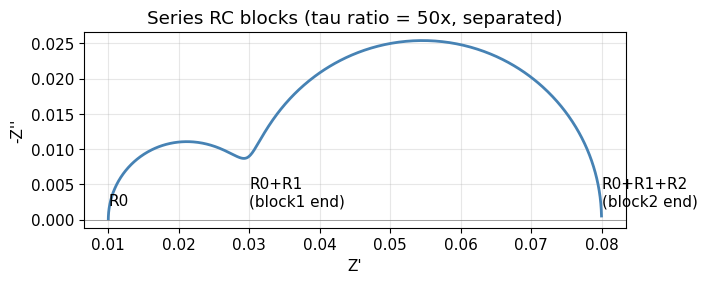

블록1 반원 지름(실측) ~ 0.02 근방이어야 함
블록2 반원 지름(실측) ~ 0.05 근방이어야 함
-> 두 개의 뚜렷이 구분되는 반원이 보이면 성공


In [4]:
R0 = 0.01
R1, C1 = 0.02, 100.0   # tau1 = 2s
R2, C2 = 0.05, 2000.0  # tau2 = 100s

print(f"tau1 = {R1*C1}s, tau2 = {R2*C2}s, 비율 = {(R2*C2)/(R1*C1):.0f}배")

omega = np.logspace(-4, 2, 1000)

Z1 = z_rc_parallel(omega, R1, C1)
Z2 = z_rc_parallel(omega, R2, C2)
Z_total = R0 + z_series(Z1, Z2)

fig, ax = plt.subplots()
ax.plot(Z_total.real, -Z_total.imag, lw=2, color='steelblue')
ax.set_xlabel("Z'")
ax.set_ylabel("-Z''")
ax.set_title('Series RC blocks (tau ratio = 50x, separated)')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5)
ax.grid(alpha=0.3)

ax.annotate('R0', (R0, 0), textcoords="offset points", xytext=(0,10))
ax.annotate('R0+R1\n(block1 end)', (R0+R1, 0), textcoords="offset points", xytext=(0,10))
ax.annotate('R0+R1+R2\n(block2 end)', (R0+R1+R2, 0), textcoords="offset points", xytext=(0,10))
plt.show()

print(f"블록1 반원 지름(실측) ~ {R1} 근방이어야 함")
print(f"블록2 반원 지름(실측) ~ {R2} 근방이어야 함")
print("-> 두 개의 뚜렷이 구분되는 반원이 보이면 성공")


## 4. 시상수가 가까운 두 RC — 반원이 뭉개지는가

W2.2에서 언급한 "τ가 가까우면(예: 2초 vs 3초) 반원이 뭉개진다"를 직접 확인.


tau1 = 2.0s, tau2 = 3.0s, 비율 = 1.5배


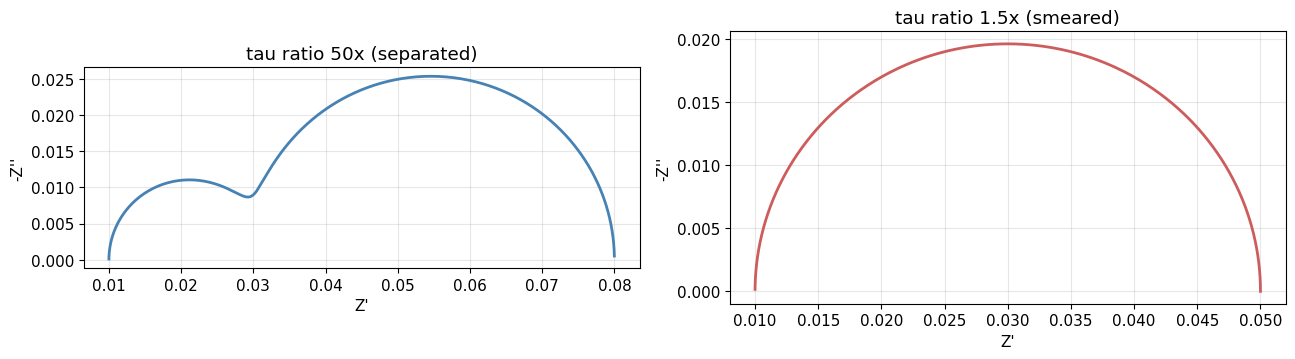

오른쪽 그림에서 두 반원의 경계가 뚜렷하지 않고 하나로 뭉개져
보이면 W2.2/W3.3에서 다룬 '시상수가 가까우면 피팅이 불안정해진다'
는 문제가 시각적으로 확인된 것.


In [5]:
R1b, C1b = 0.02, 100.0   # tau1 = 2s (동일)
R2b, C2b = 0.02, 150.0   # tau2 = 3s (가까움!)

print(f"tau1 = {R1b*C1b}s, tau2 = {R2b*C2b}s, 비율 = {(R2b*C2b)/(R1b*C1b):.1f}배")

Z1b = z_rc_parallel(omega, R1b, C1b)
Z2b = z_rc_parallel(omega, R2b, C2b)
Z_total_b = R0 + z_series(Z1b, Z2b)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].plot(Z_total.real, -Z_total.imag, lw=2, color='steelblue')
axes[0].set_title('tau ratio 50x (separated)')
axes[0].set_aspect('equal')
axes[0].set_xlabel("Z'"); axes[0].set_ylabel("-Z''")
axes[0].grid(alpha=0.3)

axes[1].plot(Z_total_b.real, -Z_total_b.imag, lw=2, color='indianred')
axes[1].set_title('tau ratio 1.5x (smeared)')
axes[1].set_aspect('equal')
axes[1].set_xlabel("Z'"); axes[1].set_ylabel("-Z''")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("오른쪽 그림에서 두 반원의 경계가 뚜렷하지 않고 하나로 뭉개져")
print("보이면 W2.2/W3.3에서 다룬 '시상수가 가까우면 피팅이 불안정해진다'")
print("는 문제가 시각적으로 확인된 것.")


## 5. 보데 선도로 같은 데이터 다시 보기 (W2.6)

나이퀴스트가 놓치는 "주파수 정보"를 보데 선도에서 확인한다.


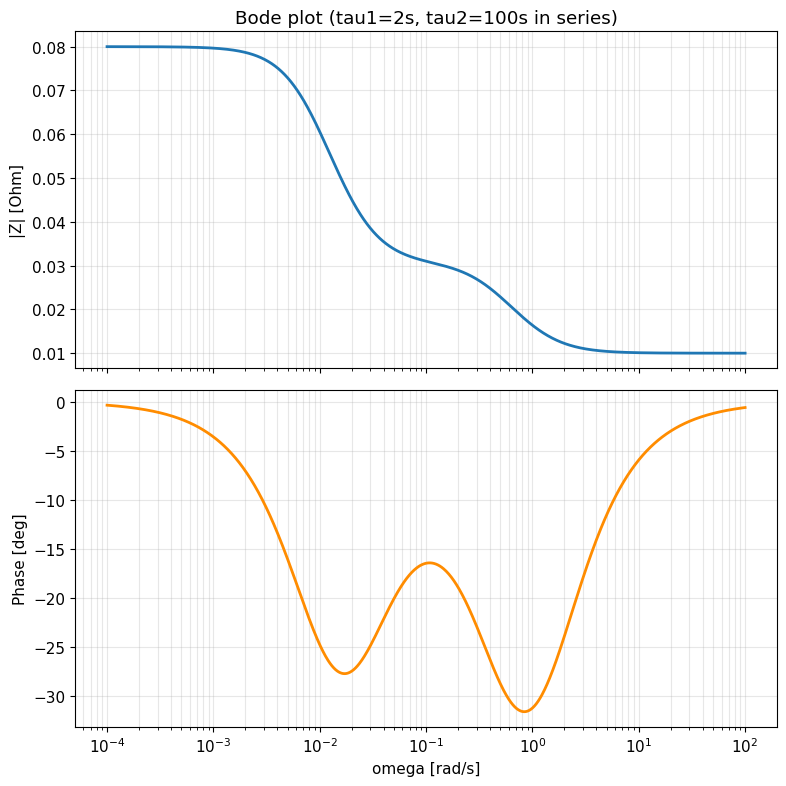

나이퀴스트에서는 안 보이던 '주파수 축'이 여기서는 명확히 보인다.
이게 W2.6에서 다룬 나이퀴스트/보데의 상호보완 관계.


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

magnitude = np.abs(Z_total)
phase = np.angle(Z_total, deg=True)

axes[0].semilogx(omega, magnitude, lw=2)
axes[0].set_ylabel('|Z| [Ohm]')
axes[0].grid(alpha=0.3, which='both')
axes[0].set_title('Bode plot (tau1=2s, tau2=100s in series)')

axes[1].semilogx(omega, phase, lw=2, color='darkorange')
axes[1].set_ylabel('Phase [deg]')
axes[1].set_xlabel('omega [rad/s]')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("나이퀴스트에서는 안 보이던 '주파수 축'이 여기서는 명확히 보인다.")
print("이게 W2.6에서 다룬 나이퀴스트/보데의 상호보완 관계.")


## 정리

- 반원 하나의 지름과 꼭대기 주파수에서 R, tau(따라서 C)를 읽어낼 수 있음을 확인
- 두 RC 블록의 tau가 충분히 다르면(50배) 반원이 분리되고,
  가까우면(1.5배) 뭉개짐을 시각적으로 확인 (W2.2, W3.3과 연결)
- 나이퀴스트와 보데가 같은 데이터의 다른 표현이며, 서로 보완적임을 확인 (W2.6)

**다음 단계**: 이 임피던스 계산에 Warburg 항(확산, W2.5)을 추가해
45도 직선과 저주파 수직상승까지 재현해보기.
